# Stock Price Prediction — Exploratory Data Analysis

This notebook explores the full S&P 500 five-year OHLCV dataset, then zooms in on
Apple Inc. (AAPL) to understand price dynamics, volume patterns, and the statistical
properties we will exploit in later modelling notebooks.

## 1. Imports & Load Data

We load the raw CSV (619 k rows across ~505 tickers) and confirm the schema before
any filtering or transformation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('data/all_stocks_5yr.csv', parse_dates=['date'])
print('Shape:', df.shape)
df.head()

Shape: (619040, 7)


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


## 2. Dataset Overview

A high-level inspection covers data types, basic statistics, duplicate rows, and
the number of unique stock tickers present.

In [2]:
print('Data types:')
print(df.dtypes)
print('\nDescriptive statistics:')
df.describe().round(2)

Data types:
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name              object
dtype: object

Descriptive statistics:


,date,open,high,low,close,volume
count,619040,619029.00,619032.00,619032.00,619040.00,6.190400e+05
mean,2015-08-18 00:48:23.494443264,83.02,83.78,82.26,83.04,4.321823e+06
min,2013-02-08 00:00:00,1.62,1.69,1.50,1.59,0.000000e+00
25%,2014-05-20 00:00:00,40.22,40.62,39.83,40.24,1.070320e+06
50%,2015-08-21 00:00:00,62.59,63.15,62.02,62.62,2.082094e+06
75%,2016-11-15 00:00:00,94.37,95.18,93.54,94.41,4.284509e+06
max,2018-02-07 00:00:00,2044.00,2067.99,2035.11,2049.00,6.182376e+08
std,NaN,97.38,98.21,96.51,97.39,8.693610e+06


In [3]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Unique tickers:', df['Name'].nunique())
print('Date range:', df['date'].min().date(), '→', df['date'].max().date())
print('Total trading days per ticker (approx):', df.groupby('Name').size().describe().round(0))

Missing values: 27


Duplicate rows: 0
Unique tickers: 505
Date range: 2013-02-08 → 2018-02-07
Total trading days per ticker (approx): count     505.0
mean     1226.0
std       161.0
min        44.0
25%      1259.0
50%      1259.0
75%      1259.0
max      1259.0
dtype: float64


## 3. AAPL Closing Price Over Time

We isolate Apple (AAPL) — the stock we will model — and plot its five-year closing
price trajectory. The chart gives an immediate sense of trend, volatility regimes,
and any large price gaps.

AAPL rows: 1259


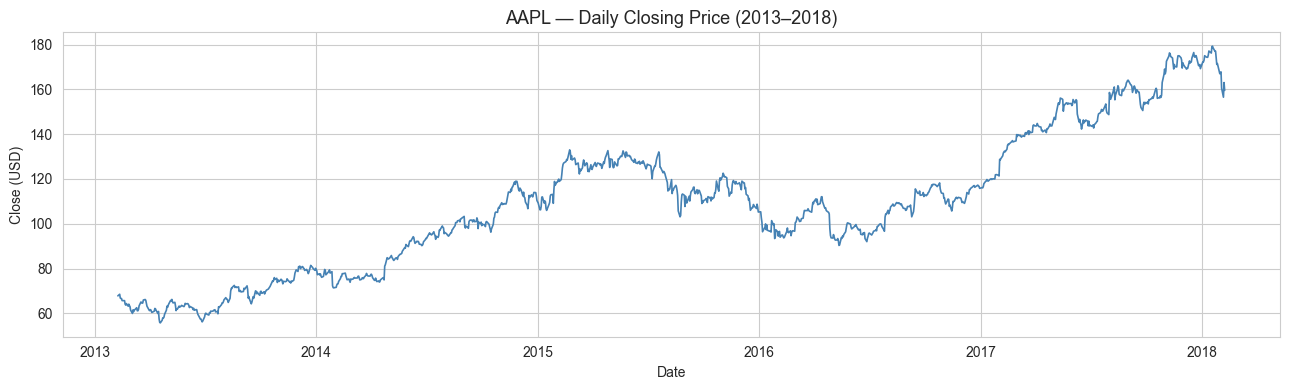

In [4]:
aapl = df[df['Name'] == 'AAPL'].copy().sort_values('date').reset_index(drop=True)
print('AAPL rows:', len(aapl))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(aapl['date'], aapl['close'], color='steelblue', linewidth=1.2)
ax.set_title('AAPL — Daily Closing Price (2013–2018)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Close (USD)')
plt.tight_layout(); plt.show()

## 4. AAPL Volume Over Time

Trading volume is an important secondary signal. High-volume spikes often coincide
with earnings releases or macro events. We plot volume as a bar chart and overlay a
30-day rolling average to smooth short-term noise.

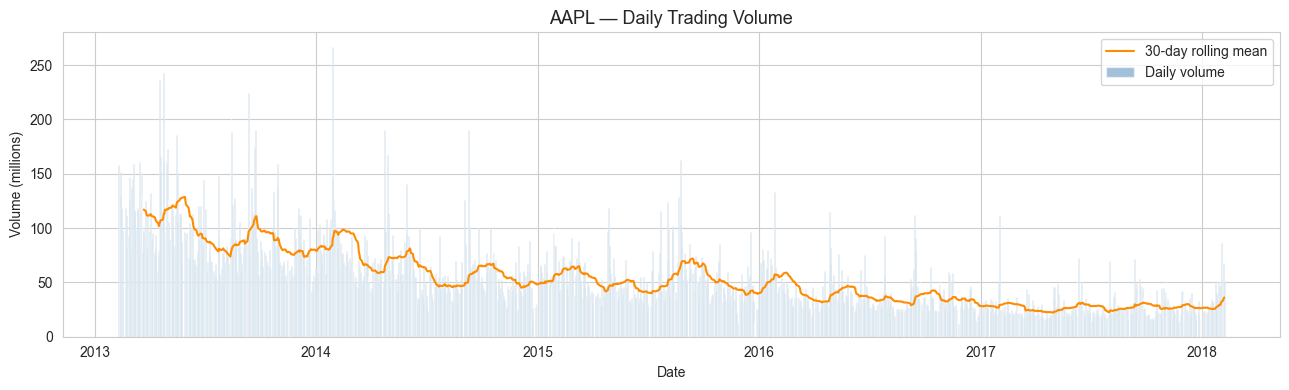

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(aapl['date'], aapl['volume'] / 1e6, color='steelblue', alpha=0.5, width=1.5, label='Daily volume')
rolling_vol = aapl['volume'].rolling(30).mean() / 1e6
ax.plot(aapl['date'], rolling_vol, color='darkorange', linewidth=1.5, label='30-day rolling mean')
ax.set_title('AAPL — Daily Trading Volume', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Volume (millions)')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Distributions of OHLCV and Daily Returns

Histograms and box plots reveal whether the price and volume distributions are
symmetric, skewed, or heavy-tailed. We also compute the daily log return, which
tends to be approximately normally distributed — a key property assumed by many
financial models.

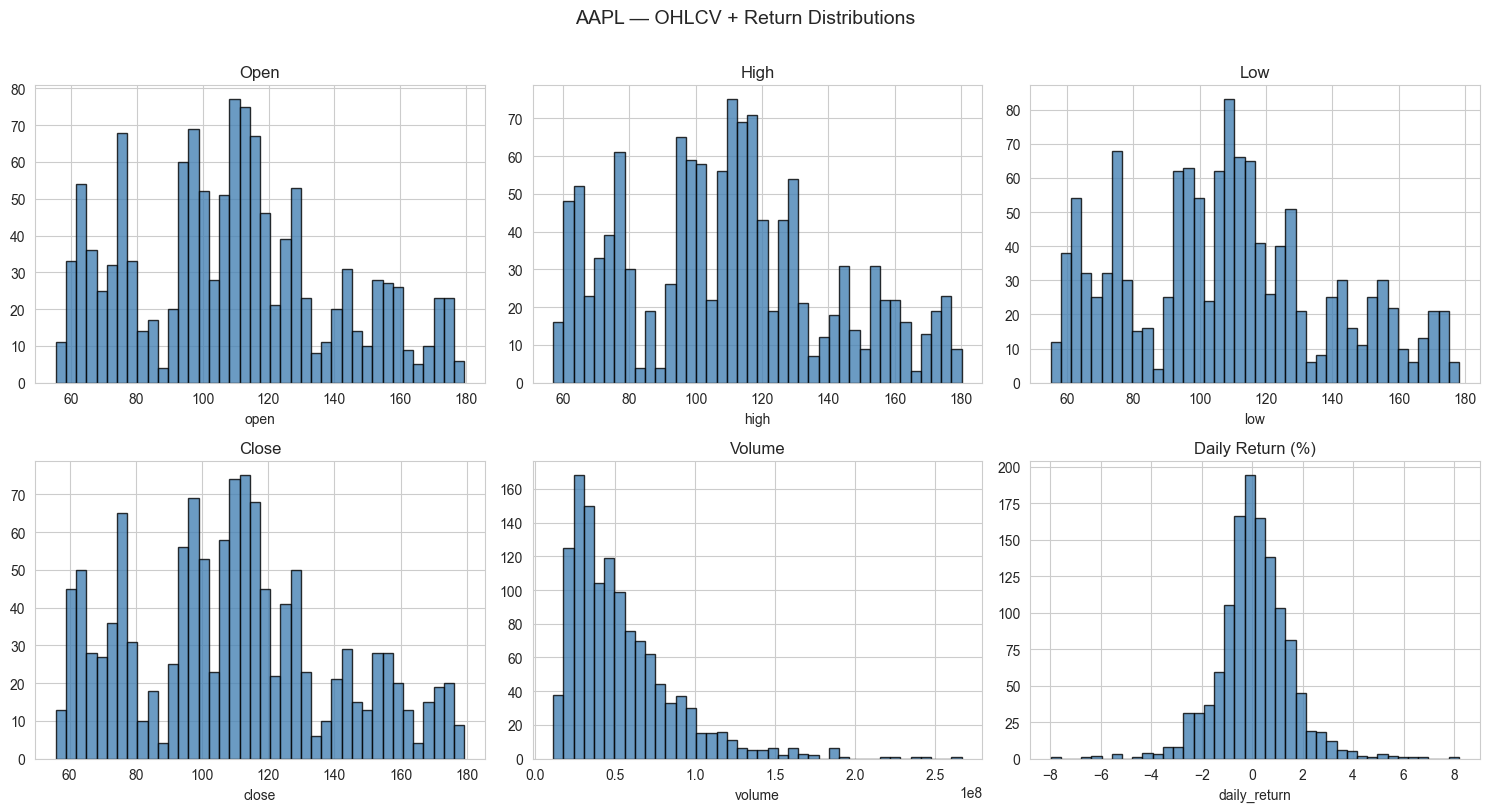

In [6]:
aapl['daily_return'] = aapl['close'].pct_change() * 100  # percent

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['open', 'high', 'low', 'close', 'volume', 'daily_return']
titles = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily Return (%)']
for ax, col, title in zip(axes.flatten(), cols, titles):
    ax.hist(aapl[col].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(col)
plt.suptitle('AAPL — OHLCV + Return Distributions', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

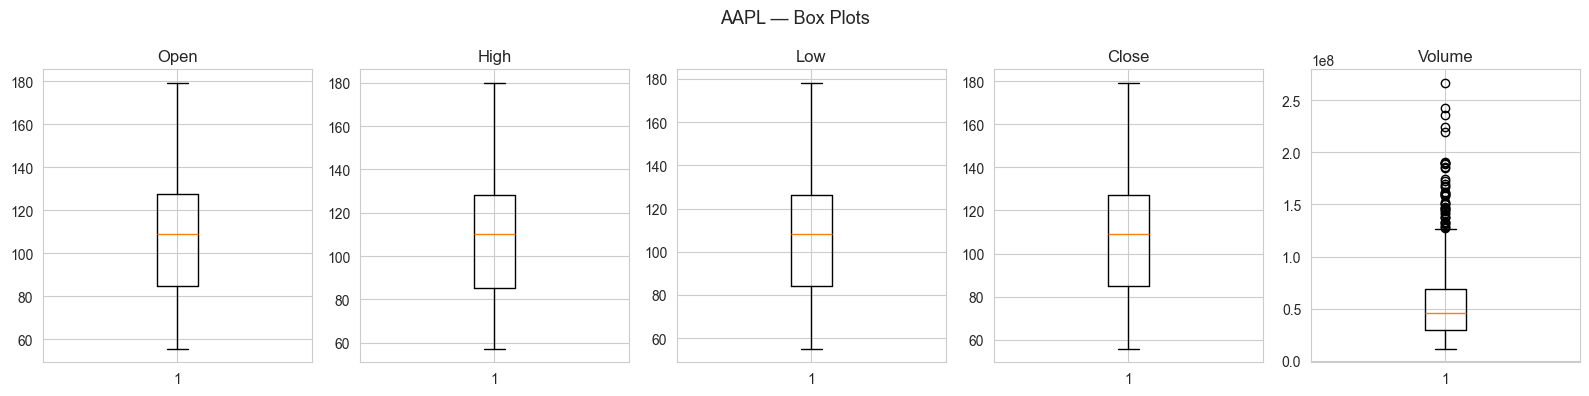

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, ['open', 'high', 'low', 'close', 'volume']):
    ax.boxplot(aapl[col].dropna(), vert=True)
    ax.set_title(col.capitalize())
plt.suptitle('AAPL — Box Plots', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Correlation Heatmap of OHLCV

OHLCV features are highly correlated with each other (open, high, low, close all
track the same underlying price level). The heatmap quantifies this. In our feature
engineering step we will create lag and rolling features to introduce genuine
predictive diversity.

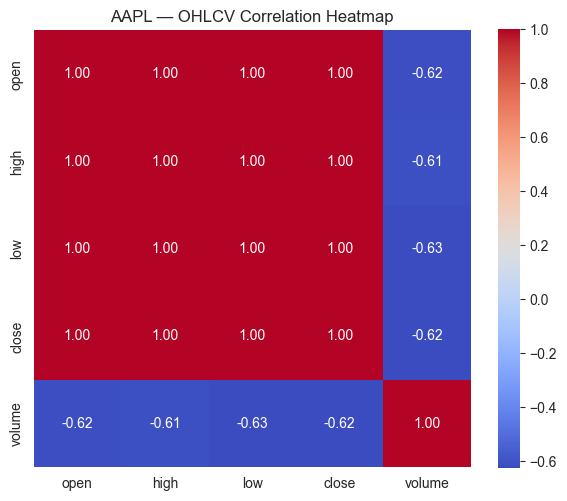

In [8]:
corr = aapl[['open', 'high', 'low', 'close', 'volume']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, square=True)
ax.set_title('AAPL — OHLCV Correlation Heatmap')
plt.tight_layout(); plt.show()

## 7. Rolling Mean Overlay & Daily-Return Distribution

Overlaying multiple moving averages (MA20, MA50) on the price chart is a standard
technical-analysis technique. The shaded area between the 20-day high and low
rolling bands illustrates volatility clustering over time.

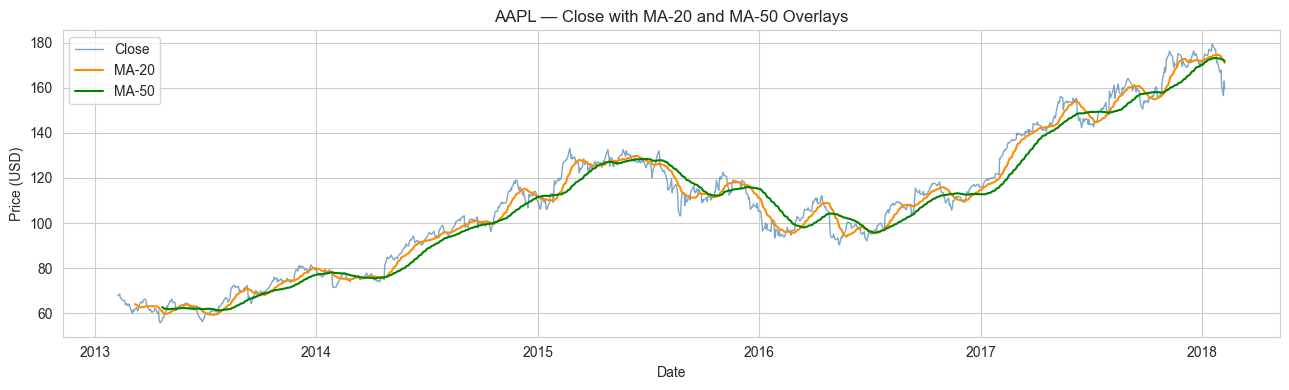

In [9]:
aapl['ma_20'] = aapl['close'].rolling(20).mean()
aapl['ma_50'] = aapl['close'].rolling(50).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(aapl['date'], aapl['close'], color='steelblue', linewidth=1.0, alpha=0.7, label='Close')
ax.plot(aapl['date'], aapl['ma_20'], color='darkorange', linewidth=1.5, label='MA-20')
ax.plot(aapl['date'], aapl['ma_50'], color='green', linewidth=1.5, label='MA-50')
ax.set_title('AAPL — Close with MA-20 and MA-50 Overlays')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)'); ax.legend()
plt.tight_layout(); plt.show()

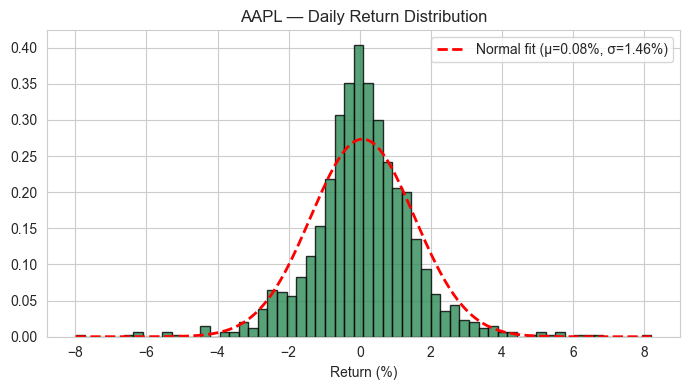

Mean daily return : 0.0786%
Std  daily return : 1.4593%
Skewness          : 0.0118
Kurtosis          : 3.7847


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
returns = aapl['daily_return'].dropna()
ax.hist(returns, bins=60, color='seagreen', edgecolor='black', alpha=0.8, density=True)
from scipy.stats import norm
mu, sigma = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 200)
ax.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label=f'Normal fit (μ={mu:.2f}%, σ={sigma:.2f}%)')
ax.set_title('AAPL — Daily Return Distribution'); ax.set_xlabel('Return (%)'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Mean daily return : {mu:.4f}%')
print(f'Std  daily return : {sigma:.4f}%')
print(f'Skewness          : {returns.skew():.4f}')
print(f'Kurtosis          : {returns.kurtosis():.4f}')

## 8. Summary of Key Findings

The table below records the main observations from EDA. These guide decisions made
in the data-cleaning and feature-engineering notebook.

In [11]:
summary = pd.DataFrame({
    'Finding': [
        'Dataset size',
        'AAPL rows',
        'Missing values',
        'Price trend',
        'Return distribution',
        'Volume trend',
        'OHLC correlation',
    ],
    'Detail': [
        f'{df.shape[0]:,} rows × {df.shape[1]} cols — {df["Name"].nunique()} unique tickers',
        f'{len(aapl):,} trading days (2013-02-08 → 2018-02-07)',
        'None — dataset is clean',
        'Strong uptrend from ~$65 to ~$175 over five years',
        f'Near-normal, μ={mu:.3f}%, σ={sigma:.3f}%; slight negative skew + fat tails',
        'Declining trend overall; sharp spikes on earnings days',
        'Open/High/Low/Close are ~0.999 correlated; volume is weakly negative',
    ]
})
summary

,Finding,Detail
0,Dataset size,"619,040 rows × 7 cols — 505 unique tickers"
1,AAPL rows,"1,259 trading days (2013-02-08 → 2018-02-07)"
2,Missing values,None — dataset is clean
3,Price trend,Strong uptrend from ~$65 to ~$175 over five years
4,Return distribution,"Near-normal, μ=0.079%, σ=1.459%; slight negati..."
5,Volume trend,Declining trend overall; sharp spikes on earni...
6,OHLC correlation,Open/High/Low/Close are ~0.999 correlated; vol...
